# RAG Case Study: When the End-to-End Score Hides a Retrieval Failure

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*  
**Subtitle**: *Design experiments that catch the improvements worth shipping*  
**Instructor**: Rudrendu Paul  
**RAG case study (5 to 6 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RudrenduPaul/statistical-testing-for-llm-evaluations/blob/main/notebooks/03-rag-evaluation-case-study.ipynb)

---

## What this notebook covers

- A simulated customer support chatbot on RAG, whose knowledge base drifts. All data is synthetic and built to show a mechanism.
- Retrieval recall falls 14 points. The end-to-end score falls 6.
- The end-to-end test fires, but only the component table shows where the drop is and how big the root cause is.
- `answer_relevance` is set to stay flat, to mimic a generator that compensates for weak retrieval. That is an assumption of the simulation, not an observed finding.

## Setup

Standard scientific Python only. No LLM API keys. Colab-safe: the install step runs only if a package fails to import.

In [1]:
import importlib
try:
    for _m in ('scipy', 'matplotlib', 'numpy', 'pandas'):
        importlib.import_module(_m)
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scipy', 'matplotlib', 'numpy', 'pandas', '--quiet'])

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)   # same numbers on every run

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
BLUE, ORANGE, RED, GREEN = '#2563EB', '#D97706', '#DC2626', '#16A34A'

def fmt_p(p):
    return 'p < 0.0001' if p < 0.0001 else f'p = {p:.4f}'

print('Libraries loaded. Ready to run.')

Libraries loaded. Ready to run.


---

## Section 1: Simulating a RAG system

500 queries before the drift (Period 1) and 500 after (Period 2). Each query gets four component scores between 0 and 1, plus the end-to-end score a dashboard would show.

| Metric | What it measures |
|---|---|
| `retrieval_recall` | Of the documents that should be retrieved, what fraction were? |
| `context_relevance` | Of the documents retrieved, what fraction is relevant? |
| `faithfulness` | Does the answer stick to the retrieved context? |
| `answer_relevance` | Does the answer address the question? |
| `end_to_end_score` | Weighted average: 0.2 retrieval, 0.2 context, 0.3 faithfulness, 0.3 answer relevance |

In Period 2 the document collection has drifted: retrieval recall drops 14 points, context relevance and faithfulness drop less, and `answer_relevance` stays flat by construction.

In [3]:
N = 500   # queries per period

# Period 1: baseline
p1_retrieval_recall  = np.clip(np.random.normal(0.82, 0.10, N), 0, 1)
p1_context_relevance = np.clip(np.random.normal(0.79, 0.09, N), 0, 1)
p1_faithfulness      = np.clip(np.random.normal(0.78, 0.11, N), 0, 1)
p1_answer_relevance  = np.clip(np.random.normal(0.81, 0.09, N), 0, 1)

# Period 2: after document drift. Answer relevance keeps the same mean by assumption.
p2_retrieval_recall  = np.clip(np.random.normal(0.68, 0.11, N), 0, 1)
p2_context_relevance = np.clip(np.random.normal(0.72, 0.10, N), 0, 1)
p2_faithfulness      = np.clip(np.random.normal(0.73, 0.11, N), 0, 1)
p2_answer_relevance  = np.clip(np.random.normal(0.81, 0.09, N), 0, 1)

def composite(recall, context, faith, answer):
    return 0.20 * recall + 0.20 * context + 0.30 * faith + 0.30 * answer

metrics = ['retrieval_recall', 'context_relevance', 'faithfulness', 'answer_relevance']
df_p1 = pd.DataFrame({'period': 'Period 1 (Baseline)',
                      'retrieval_recall': p1_retrieval_recall, 'context_relevance': p1_context_relevance,
                      'faithfulness': p1_faithfulness, 'answer_relevance': p1_answer_relevance,
                      'end_to_end_score': composite(p1_retrieval_recall, p1_context_relevance, p1_faithfulness, p1_answer_relevance)})
df_p2 = pd.DataFrame({'period': 'Period 2 (Post-Drift)',
                      'retrieval_recall': p2_retrieval_recall, 'context_relevance': p2_context_relevance,
                      'faithfulness': p2_faithfulness, 'answer_relevance': p2_answer_relevance,
                      'end_to_end_score': composite(p2_retrieval_recall, p2_context_relevance, p2_faithfulness, p2_answer_relevance)})
df = pd.concat([df_p1, df_p2], ignore_index=True)

print(f'Dataset: {len(df)} rows ({N} per period)\n')
print('Period-level means:')
print(df.groupby('period')[metrics + ['end_to_end_score']].mean().round(3).T.to_string())

Dataset: 1000 rows (500 per period)

Period-level means:
period             Period 1 (Baseline)  Period 2 (Post-Drift)
retrieval_recall                 0.819                  0.679
context_relevance                0.793                  0.722
faithfulness                     0.791                  0.728
answer_relevance                 0.812                  0.808
end_to_end_score                 0.803                  0.741


---

## Section 2: What the dashboard sees

A dashboard tracks one number, the end-to-end score, and alerts on a drop of more than 5 points. The team runs a Mann-Whitney test on the two periods to decide whether to escalate.

In [4]:
e2e_p1 = df_p1['end_to_end_score'].values
e2e_p2 = df_p2['end_to_end_score'].values

# One-sided: is Period 1 stochastically greater than Period 2 (did the score decline)?
_, pval_e2e = stats.mannwhitneyu(e2e_p1, e2e_p2, alternative='greater')
drop_e2e = e2e_p1.mean() - e2e_p2.mean()

print('=== End-to-End Score Comparison ===')
print(f'  Period 1 mean : {e2e_p1.mean():.4f}')
print(f'  Period 2 mean : {e2e_p2.mean():.4f}')
print(f'  Drop          : {drop_e2e:.4f} ({drop_e2e * 100:.1f} percentage points)')
print(f'  p-value       : {fmt_p(pval_e2e)}')
print()
if pval_e2e < 0.05:
    print('ALERT: the end-to-end score declined significantly.')
    print(f'It reads as a {drop_e2e * 100:.0f}-point drop. It does not say which component broke.')

=== End-to-End Score Comparison ===
  Period 1 mean : 0.8033
  Period 2 mean : 0.7408
  Drop          : 0.0625 (6.2 percentage points)
  p-value       : p < 0.0001

ALERT: the end-to-end score declined significantly.
It reads as a 6-point drop. It does not say which component broke.


**What this shows**: the test fires, so the alert is valid. What the number cannot tell you is where the drop came from or how large the root cause is.

---

## Section 3: The component view

Run the same test on each component separately.

In [5]:
rows = []
for m in metrics:
    v1, v2 = df_p1[m].values, df_p2[m].values
    _, p = stats.mannwhitneyu(v1, v2, alternative='greater')
    rows.append({'Metric': m, 'Mean P1': round(v1.mean(), 3), 'Mean P2': round(v2.mean(), 3),
                 'Drop (pp)': round((v1.mean() - v2.mean()) * 100, 1),
                 'p-value': '< 0.0001' if p < 0.0001 else f'{p:.4f}',
                 'Significant': p < 0.05})
results_df = pd.DataFrame(rows).set_index('Metric')

print('=== Component-Level Comparison ===\n')
print(results_df.to_string())
print()
d = results_df['Drop (pp)']
print(f'Composite drop from the weights: 0.2*{d["retrieval_recall"]:.1f} + 0.2*{d["context_relevance"]:.1f} + '
      f'0.3*{d["faithfulness"]:.1f} + 0.3*{d["answer_relevance"]:.1f} = '
      f'{0.2 * d["retrieval_recall"] + 0.2 * d["context_relevance"] + 0.3 * d["faithfulness"] + 0.3 * d["answer_relevance"]:.1f}pp')
print(f'Retrieval recall drop: {d["retrieval_recall"]:.1f}pp. End-to-end drop: {drop_e2e * 100:.1f}pp.')

=== Component-Level Comparison ===

                   Mean P1  Mean P2  Drop (pp)   p-value  Significant
Metric                                                               
retrieval_recall     0.819    0.679       14.0  < 0.0001         True
context_relevance    0.793    0.722        7.1  < 0.0001         True
faithfulness         0.791    0.728        6.3  < 0.0001         True
answer_relevance     0.812    0.808        0.5    0.1912        False

Composite drop from the weights: 0.2*14.0 + 0.2*7.1 + 0.3*6.3 + 0.3*0.5 = 6.3pp
Retrieval recall drop: 14.0pp. End-to-end drop: 6.2pp.


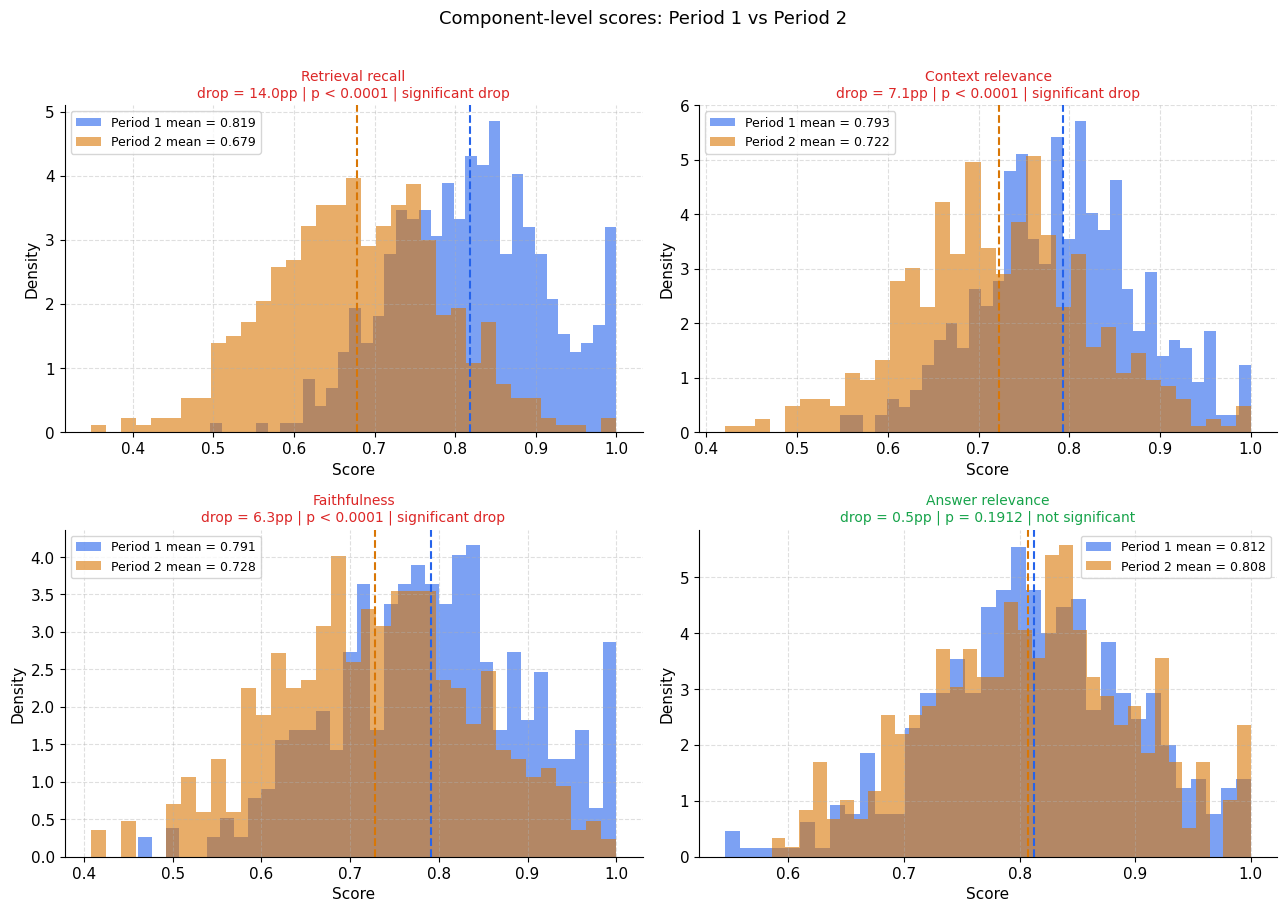

Top-left: retrieval recall fell 14 points. Bottom-right: answer relevance looks unchanged.
The end-to-end score averaged these together into a single 6 point drop.


In [6]:
labels = {'retrieval_recall': 'Retrieval recall', 'context_relevance': 'Context relevance',
          'faithfulness': 'Faithfulness', 'answer_relevance': 'Answer relevance'}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, m in zip(axes.flatten(), metrics):
    v1, v2 = df_p1[m].values, df_p2[m].values
    row = results_df.loc[m]
    ax.hist(v1, bins=35, alpha=0.60, color=BLUE, density=True, label=f'Period 1 mean = {v1.mean():.3f}')
    ax.hist(v2, bins=35, alpha=0.60, color=ORANGE, density=True, label=f'Period 2 mean = {v2.mean():.3f}')
    ax.axvline(v1.mean(), color=BLUE, linestyle='--', linewidth=1.5)
    ax.axvline(v2.mean(), color=ORANGE, linestyle='--', linewidth=1.5)
    color = RED if row['Significant'] else GREEN
    verdict = 'significant drop' if row['Significant'] else 'not significant'
    p_text = 'p ' + row['p-value'] if row['p-value'].startswith('<') else 'p = ' + row['p-value']
    ax.set_title(f'{labels[m]}\ndrop = {row["Drop (pp)"]:.1f}pp | {p_text} | {verdict}', color=color, fontsize=10, pad=6)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
fig.suptitle('Component-level scores: Period 1 vs Period 2', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Top-left: retrieval recall fell 14 points. Bottom-right: answer relevance looks unchanged.')
print('The end-to-end score averaged these together into a single 6 point drop.')

---

## Takeaway

- The end-to-end score is a weighted average. Drops of 14, 7, 6 and 0 points average to about 6, so a 14 point retrieval failure reaches the dashboard as a 6 point alert.
- The alert fires, but it cannot say which component broke. The component table can: retrieval recall.
- Track each component, not only the composite.

*This notebook accompanies the O'Reilly Live Course: **Statistical Testing for LLM Evaluations**, by Rudrendu Paul. All data is simulated.*